In [1]:
import numpy as np
import matplotlib.pyplot as plt
import os
import glob
from scipy.interpolate import interp1d
from scipy.interpolate import interp2d
from matplotlib.pyplot import cycler
from matplotlib.colors import LinearSegmentedColormap, ListedColormap
from matplotlib.patches import Patch

import xarray as xr

path = os.getcwd().split('/')
machine_path = '/'+path[1]+'/'+path[2]


In [19]:
def plot_layers_rheology(ax, subplot_title, interfaces, x, z, dx, dz, Lx, Lz, ylims, thickness_sa=40.0e3, preliminary=False, xlabel=True):

    cr = 255.
    color_air = "xkcd:white"
    color_uc = (228./cr,156./cr,124./cr)
    color_lc = (240./cr,209./cr,188./cr)
    color_lit = (155./cr,194./cr,155./cr)
    color_ast = (207./cr,226./cr,205./cr)

    colors = {'air': color_uc,
                'upper_crust': color_lc,
                'lower_crust': color_lit,
                'litho_nc': color_ast,}
    labels = {
            'air': 'Upper crust',
            'upper_crust': 'Lower crust',
            'lower_crust': 'Lithospheric mantle',
            'litho_nc': 'Asthenosphere',#'Upper cratonic lithospheric mantle',
        }


    #######Creating subplot a) Preliminary Scenario
    ax.text(0.0, 1.1, subplot_title, transform=ax.transAxes, fontsize=12, va='top')
    for interface in list(interfaces.items())[::-1]:
        label, layer = interface[0], interface[1]
        ax.fill_between(x/1000, -layer/1000+thickness_sa/1000, -Lz/1000+thickness_sa/1000, color=colors[label])#, label=labels_preliminary[label])

    
    ax.set_xlim(0, Lx/1000)
    ax.set_ylim(ylims)
    ax.set_xticks([])
    ax.set_yticks([])
    if(preliminary==True):
        if(xlabel==True):
            ax.set_xlabel(r"$L_{0_x}$ = "+f"{Lx/1000:.0f} km\nResolution = {dx/1000:.0f} km", fontsize=12)
        ax.set_ylabel(r"$L_{0_z}$ = "+f"{Lz/1000:.0f} km\nResolution = {dz/1000:.0f} km", fontsize=12)
    else:
        if (xlabel==True):
            ax.set_xlabel(r"$L_{x}$ = "+f"{Lx/1000:.0f} km\nResolution = {dx/1000:.0f} km", fontsize=12)
        ax.set_ylabel(r"$L_{z}$ = "+f"{Lz/1000:.0f} km\nResolution = {dz/1000:.0f} km", fontsize=12)

def calc_velocity_field(x, z, Nx, Nz, X, Z, Lx, Lz, thickness_sa, thickness_mlit, velocity = 1.0):

    #Velocity field #cm/year
    fac_air = 10.0e3

    # 1 cm/year
    vL = (0.5*velocity/100) / (365 * 24 * 3600)  # m/s

    h_v_const = thickness_mlit + 20.0e3  #thickness with constant velocity 
    ha = Lz - thickness_sa - h_v_const  # difference

    vR = 2 * vL * (h_v_const + fac_air + ha) / ha  # this is to ensure integral equals zero

    VX = np.zeros_like(X)
    cond = (Z > h_v_const + thickness_sa) & (X == 0)
    VX[cond] = vR * (Z[cond] - h_v_const - thickness_sa) / ha

    cond = (Z > h_v_const + thickness_sa) & (X == Lx)
    VX[cond] = -vR * (Z[cond] - h_v_const - thickness_sa) / ha

    cond = X == Lx
    VX[cond] += +2 * vL

    cond = Z <= thickness_sa - fac_air
    VX[cond] = 0

    # print(np.sum(VX))

    v0 = VX[(X == 0)]
    vf = VX[(X == Lx)]
    sv0 = np.sum(v0[1:-1]) + (v0[0] + v0[-1]) / 2.0
    svf = np.sum(vf[1:-1]) + (vf[0] + vf[-1]) / 2.0

    diff = (svf - sv0) * dz

    vv = -diff / Lx

    VZ = np.zeros_like(X)

    cond = Z == 0
    VZ[cond] = vv
    #save bc to plot arraows in numerical setup
    vels_bc = np.array([v0, vf])
    vz0 = VZ[(z == 0)]

    VVX = np.copy(np.reshape(VX, Nx * Nz))
    VVZ = np.copy(np.reshape(VZ, Nx * Nz))

    v = np.zeros((2, Nx * Nz))

    v[0, :] = VVX
    v[1, :] = VVZ

    v = np.reshape(v.T, (np.size(v)))

    return VX

def plot_velocity_field(ax, z, Lz, thickness_sa, VX, velocity):
    #Plot Velocity = Right side
    vr_plot = np.round(max(abs(VX[:, -1]* (100.0*365.0 * 24.0 * 3600.0))),0)
    fac = 0.96
    axr = ax.inset_axes((fac,
                        0,
                        (1-fac)*2,
                        1))

    scale_veloc = 100.0*365.0*24.0*3600.0
    crt=0

    #Right side velocity arrows
    axr.fill_betweenx((-z + thickness_sa) / 1.0e3, VX[:, -1]* (100.0*365.0 * 24.0 * 3600.0), 0, color=None, facecolor=None, hatch='---',alpha=0)
    axr.set_ylim(ylimplot)
    axr.set_yticks([])
    axr.set_xticks([])
    axr.patch.set_alpha(0)
    axr.set_title(f'v [cm/y]', fontsize=8)
    # axr.xaxis.set_ticks_position('top')
    axr.tick_params(labelsize=8)
    axr.set_xlim([-vr_plot, vr_plot])
    axr.spines['left'].set_visible(False)
    axr.spines['right'].set_visible(False)
    axr.spines['bottom'].set_visible(False)

    # Left side velocity arrows
    vl_plot = np.round(max(abs(VX[:, 0]* (100*365.0 * 24.0 * 3600.0))), 0)
    axl = ax.inset_axes((0,
                            0,
                            (1-fac)*2,
                            1))

    axl.fill_betweenx((-z + thickness_sa) / 1.0e3, VX[:, 0]* (100*365 * 24 * 3600), 0, color=None, facecolor=None, hatch='---',alpha=0)

    axl.set_ylim(-Lz/1000+thickness_sa/1000, 0+thickness_sa/1000)
    axl.set_yticks([])
    axl.set_xticks([])
    axl.patch.set_alpha(0)
    # axl.set_title(f'v = {v} cm/y')
    # axl.xaxis.set_ticks_position('top')
    axl.set_xlim([0, 2*velocity])
    # axl.set_xlim([0, vl_plot])
    axl.tick_params(labelsize=8)
    axl.spines['left'].set_visible(False)
    axl.spines['right'].set_visible(False)

def plot_effective_friction_angle(ax):
    axsf = ax.inset_axes((0.150,
                        0.0,
                        0.135,
                        0.58))
    axsf.patch.set_alpha(0.4)

    # xdata = np.array([0, 0.05, 1.05, 1.1])
    xdata = np.array([0, 0.25, 0.75, 1.0])
    ydata = np.array([15, 15, 2, 2])

    fisize = 9
    axsf.plot(xdata, ydata, 'k-')
    axsf.set_xlim([0.10, 0.9])
    axsf.set_ylim([0, 17])
    axsf.set_xticks([0.25, 0.5, 0.75])
    axsf.set_xticklabels([0.05, ' ', 1.05])
    axsf.tick_params('x', top=True, labeltop=False)
    axsf.xaxis.set_ticks_position('bottom')
    axsf.set_xlabel(r"$\varepsilon$", fontsize=fisize)

    axsf.set_yticks([2, 15])
    axsf.set_yticklabels(['2°', '15°'])
    axsf.set_ylabel(r'$\varphi_{\mathrm{eff}}$', fontsize=fisize)
    axsf.tick_params(labelsize=fisize)

    axsfC = axsf.twinx()
    axsfC.set_ylim([0, 17])
    axsfC.set_yticks([2, 15])
    axsfC.set_yticklabels([4, 20])
    axsfC.set_ylabel('Cohesion [MPa]', fontsize=fisize, rotation=90)
    axsfC.tick_params(labelsize=fisize)

def plot_mantle_regions(ax, Lx, Lz, dx, dz, thickness_sa, xpos = 1150, fsize = 10, scale=1.0):
    color_mlit_upper='xkcd:bright purple'#'xkcd:cerulean blue'
    color_mlit_intermediate='xkcd:dark green'#'xkcd:scarlet'
    color_mlit_lower='xkcd:bright orange'#'xkcd:dark green'

    #Upper mantle lithosphere
    ax.plot([xpos, xpos], [(-75+thickness_sa/1000)*scale, (-105+thickness_sa/1000)*scale], color=color_mlit_upper) #vertical bar
    ax.plot([xpos-10, xpos+10], [(-75+thickness_sa/1000)*scale, (-75+thickness_sa/1000)*scale], color=color_mlit_upper) #upper horizontal bar
    ax.plot([xpos-10, xpos+10], [(-105+thickness_sa/1000)*scale, (-105+thickness_sa/1000)*scale], color=color_mlit_upper) #base of litho
    ax.text(xpos+20, (-90+thickness_sa/1000)*scale, r"Upper lithospheric mantle", fontsize=fsize-2, color=color_mlit_upper)
    ax.text(xpos-90, (-90+thickness_sa/1000)*scale, r"30 km", fontsize=fsize-2, color=color_mlit_upper)

    #Intermediate mantle lithosphere
    ax.plot([xpos, xpos], [(-105+thickness_sa/1000)*scale, (-135+thickness_sa/1000)*scale], color=color_mlit_intermediate) #vertical bar
    ax.plot([xpos-10, xpos+10], [(-105+thickness_sa/1000)*scale, (-105+thickness_sa/1000)*scale], color=color_mlit_intermediate) #upper horizontal bar
    ax.plot([xpos-10, xpos+10], [(-135+thickness_sa/1000)*scale, (-135+thickness_sa/1000)*scale], color=color_mlit_intermediate) #base of litho
    ax.text(xpos+20, (-120+thickness_sa/1000)*scale, r"Intermediate lithospheric mantle", fontsize=fsize-2, color=color_mlit_intermediate)
    ax.text(xpos-90, (-120+thickness_sa/1000)*scale, r"30 km", fontsize=fsize-2, color=color_mlit_intermediate)

    #Lower mantle lithosphere
    ax.plot([xpos, xpos], [(-135+thickness_sa/1000)*scale, (-160+thickness_sa/1000)*scale], color=color_mlit_lower) #vertical bar
    ax.plot([xpos-10, xpos+10], [(-135+thickness_sa/1000)*scale, (-135+thickness_sa/1000)*scale], color=color_mlit_lower) #upper horizontal bar
    ax.plot([xpos-10, xpos+10], [(-160+thickness_sa/1000)*scale, (-160+thickness_sa/1000)*scale], color=color_mlit_lower) #base of litho
    ax.text(xpos+20, (-150+thickness_sa/1000)*scale, r"Lower lithospheric mantle", fontsize=fsize-2, color=color_mlit_lower)
    ax.text(xpos-125, (-150+thickness_sa/1000)*scale, r"20-25 km", fontsize=fsize-2, color=color_mlit_lower)

    ax.set_xlim(0, Lx/1000)
    ax.set_ylim(-Lz/1000+thickness_sa/1000, 0+thickness_sa/1000)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.text(0.0, 1.1, 'c) Heterogeneous scenarios', transform=axs[2].transAxes, fontsize=12, va='top')
    ax.set_xlabel(f"$L_x$ = {Lx/1000:.0f} km\nResolution = {dx/1000:.0f} km", fontsize=12)
    ax.set_ylabel(f"$L_z$ = {Lz/1000:.0f} km\nResolution = {dz/1000:.0f} km", fontsize=12)

def calc_temperature_profile_diffusion(z, dz, X, Z, thickness_sa, thickness_upper_crust, thickness_lower_crust, TP=1262, DeltaT=230):
    T = 1300 * (z - thickness_sa) / (thickness_litho0)  # Temperature
        
    # T = 1300 * (z - thickness_sa) / (130*1.0E3)  # Temperature of 1300 isotherm bellow the lithosphere

    ccapacity = 1250*1.0 #937.5=75% #J/kg/K? #DEFAULT

    TP = 1262 #mantle potential temperature
    # TP = 1350
    # TP = 1400
    # TP = 1450

    Ta = (TP / np.exp(-10 * 3.28e-5 * (z - thickness_sa) / ccapacity)) + DeltaT #Temperature profile for asthenosphere

    T[T < 0.0] = 0.0 #forcing negative temperatures to 0
    cond1 = Ta<T #VICTOR - selecting where asthenosphere temperature is lower than lithospheric temperature
    T[T > Ta] = Ta[T > Ta] #apply the temperature of asthenosphere (Ta) where temperature (T) is greater than Ta

    # kappa = 0.75*1.0e-6 #thermal diffusivity
    kappa = 1.0e-6 #thermal diffusivity
    Huc = 2.5e-6 / 2700.0
    H = np.zeros_like(T)
    cond = (z >= thickness_sa) & (z < thickness_sa + thickness_upper_crust + thickness_lower_crust)  # upper crust
    H[cond] = Huc

    cond = (z >= thickness_sa + thickness_upper_crust) & (z < thickness_sa + thickness_upper_crust + thickness_lower_crust)  # lower crust

    Hlc = 0.8e-6 / 2800.0
    H[cond] = Hlc

    #Conductive model
    Taux = np.copy(T)

    t = 0
    dt = 5000
    dt_sec = dt * 365 * 24 * 3600
    # cond = (z > thickness_sa + thickness_litho) | (T == 0)  # (T > 1300) | (T == 0) #OLD
    cond = cond1 | (T == 0)  # (T > 1300) | (T == 0) #VICTOR
    dz = L0z / (N0z - 1)

    while t < 2000.0e6:
        #non-cratonic region
        T[1:-1] += (
            kappa * dt_sec * ((T[2:] + T[:-2] - 2 * T[1:-1]) / dz ** 2)
            + H[1:-1] * dt_sec / ccapacity
        )
        T[cond] = Taux[cond]

        t = t + dt

    T = np.ones_like(X) * T[:, None] #(Nz, Nx)

    return T

def plot_temperature_profile(ax, temperature, z, ylims, thickness_sa=40.0e3, label=' '):
    axt1 = ax.inset_axes((0.25,
                        0,
                        0.2,
                        1))

    axt1.plot(temperature, (-z + thickness_sa) / 1.0e3, "-r")# label=r'T$_{\mathrm{non-cratonic}}$')

    axt1.plot([-10, -10], '-', color='k', label=label)
    axt1.legend(loc='lower left', labelcolor='k', handlelength=0, handletextpad=0, fontsize=12)

    axt1.grid(visible=True, axis='x',which='both',ls='--',color='red',alpha=0.3)
    axt1.set_ylim(ylims)
    axt1.set_yticks([])
    axt1.set_xticks(np.linspace(0,1500,6))
    axt1.patch.set_alpha(0)
    axt1.xaxis.set_ticks_position('top')
    axt1.set_yticks([])
    axt1.tick_params(labelsize=8)
    axt1.xaxis.label.set_color('red')
    axt1.tick_params(axis='x', colors='k')
    axt1.spines['left'].set_visible(False)
    axt1.spines['right'].set_visible(False)
    axt1.set_title('Temperature [°C]',color='k')

def calc_YSE(T, z, dz,
                            C_air, C_upper_crust, C_lower_crust, C_mlit, C_ast,
                            rho_air, rho_upper_crust, rho_lower_crust, rho_mlit, rho_ast,
                            H_air, H_upper_crust, H_lower_crust, H_mlit, H_ast,
                            A_air, A_upper_crust, A_lower_crust, A_mlit, A_ast,
                            n_air, n_upper_crust, n_lower_crust, n_mlit, n_ast,
                            Q_air, Q_upper_crust, Q_lower_crust, Q_mlit, Q_ast,
                            V_air, V_upper_crust, V_lower_crust, V_mlit, V_ast,
                            thickness_sa = 40 * 1.0e3,
                            thickness_upper_crust = 20 * 1.0e3,
                            thickness_lower_crust = 15 * 1.0e3,
                            thickness_mlit = 45 * 1.0e3,
                            thickness_litho = 80 * 1.0e3):
    
    zaux = z
    #conditions for regions
    air = zaux < thickness_sa
    uc = (zaux>=thickness_sa) & (zaux<thickness_sa+thickness_upper_crust)
    lc = (zaux>=thickness_sa+thickness_upper_crust) & (zaux<thickness_sa+thickness_upper_crust+thickness_lower_crust)
    lm = (zaux>=thickness_sa+thickness_upper_crust+thickness_lower_crust) & (zaux<=thickness_sa+thickness_upper_crust+thickness_lower_crust+thickness_mlit)
    astnc = zaux>thickness_sa+thickness_upper_crust+thickness_lower_crust+thickness_mlit

    Q = np.zeros_like(z)
    A = np.zeros_like(z)
    n = np.zeros_like(z)
    V = np.zeros_like(z)
    C = np.zeros_like(z)
    rho = np.zeros_like(z)

    #non cratonic rheological properties
    C[air] = C_air
    C[uc] = C_upper_crust
    C[lc] = C_lower_crust
    C[lm] = C_mlit
    C[astnc] = C_ast

    rho[air] = rho_air
    rho[uc] = rho_upper_crust
    rho[lc] = rho_lower_crust
    rho[lm] = rho_mlit
    rho[astnc] = rho_ast

    A[air] = A_air
    A[uc] = A_upper_crust
    A[lc] = A_lower_crust
    A[lm] = A_mlit
    A[astnc] = A_ast

    n[air] = n_air
    n[uc] = n_upper_crust
    n[lc] = n_lower_crust
    n[lm] = n_mlit
    n[astnc] = n_ast

    Q[air] = Q_air
    Q[uc] = Q_upper_crust
    Q[lc] = Q_lower_crust
    Q[lm] = Q_mlit
    Q[astnc] = Q_ast

    V[air] = V_air
    V[uc] = V_upper_crust
    V[lc] = V_lower_crust
    V[lm] = V_mlit
    V[astnc] = V_ast

    sr = 1.0E-15 #strain rate - s-1
    # sr = 1.0E-14
    R = 8.314 #gas constant - J K−1 mol−1
    g = 10.0

    P = rho[::-1].cumsum()[::-1]*g*dz

    phi = 2.0*np.pi/180.0
    c0 = 4.0E6

    sigma_min = c0 * np.cos(phi) + P * np.sin(phi)

    phi = 15.0*np.pi/180.0
    c0 = 20.0E6
    sigma_max = c0 * np.cos(phi) + P * np.sin(phi)

    TK = T + 273

    visc = C * A**(-1./n) * sr**((1.0-n)/n)*np.exp((Q + V*P)/(n*R*TK))
    sigma_v = visc * sr
    cond = sigma_v>sigma_max
    sigma_v[cond]=sigma_max[cond]

    sigma_v[air] = 0.0
    return sigma_v

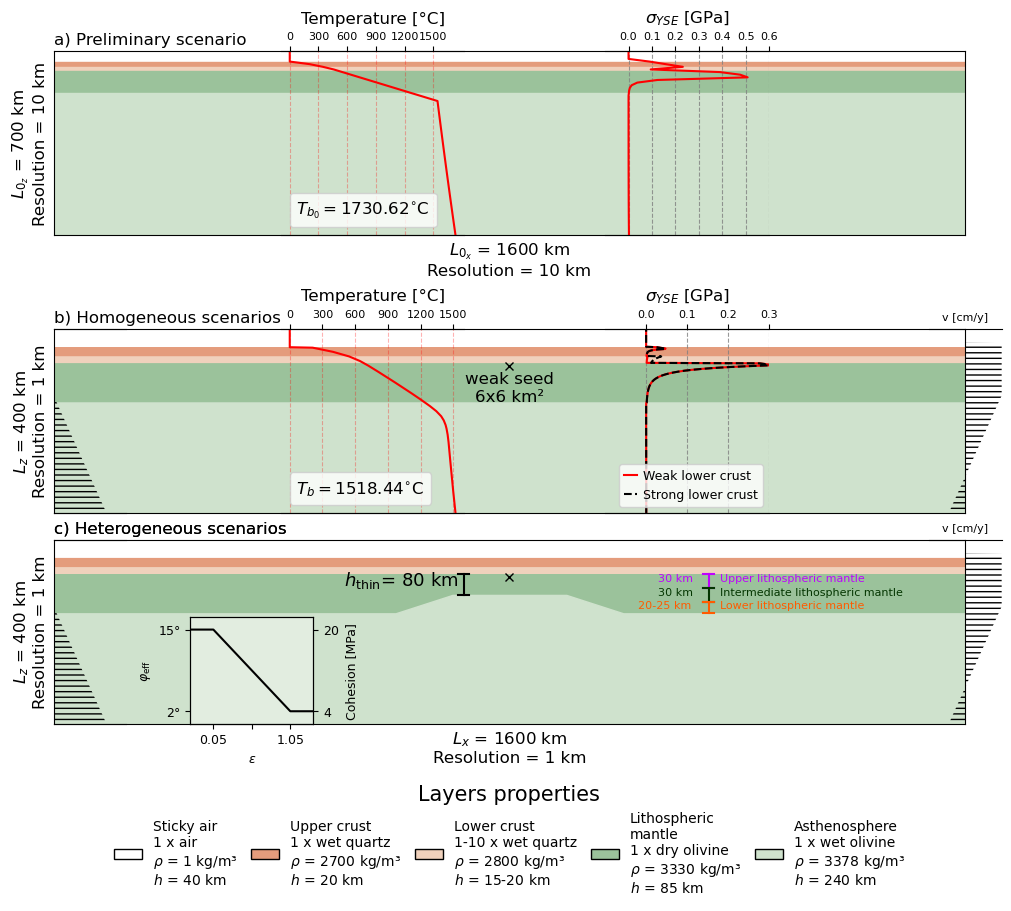

In [20]:
plt.close()
fig, axs = plt.subplots(3, 1, figsize=(10, 9), constrained_layout=True)

#Domain of Preliminary scenario
L0x = 1600.0e3 #m
L0z = 700.0e3 #m
N0x = 161
N0z = 71
dx0 = L0x/(N0x-1)
dz0 = L0z/(N0z-1)
x0 = np.linspace(0, L0x, N0x)
z0 = np.linspace(L0z, 0, N0z)
X0, Z0 = np.meshgrid(x0, z0)

#Domain of Rifting scenarios
Lx = 1600.0e3 #m
Lz = 400.0e3 #m
Nx = 1601
Nz = 401
dx = Lx/(Nx-1)
dz = Lz/(Nz-1)
x = np.linspace(0, Lx, Nx)
z = np.linspace(Lz, 0, Nz)
X, Z = np.meshgrid(x, z)

# thickness of sticky air layer (m)
thickness_sa = 40 * 1.0e3
# thickness of upper crust (m)
thickness_upper_crust = 20 * 1.0e3
# thickness of lower crust (m)
thickness_lower_crust = 15 * 1.0e3
#Thickness of non cratonic lithosphere
thickness_mlit0 = 85 * 1.0e3
thickness_mlit = 85 * 1.0e3
#Thickness of asthenosphere
thickness_ast0 = L0z - (thickness_sa + thickness_upper_crust + thickness_lower_crust + thickness_mlit0) #Preliminary asthenosphere thickness
thickness_ast = Lz - (thickness_sa + thickness_upper_crust + thickness_lower_crust + thickness_mlit) #Rifting asthenosphere thickness
#Total thickness of lithosphere
thickness_litho = thickness_upper_crust + thickness_lower_crust + thickness_mlit
thickness_litho0 = thickness_upper_crust + thickness_lower_crust + thickness_mlit0

#Viscosity scale factor
C_air = 1.0
C_upper_crust = 1.0
C_lower_crust = 10.0
C_seed = 0.1
C_mlit = 1.0
C_ast = 1.0

#density (kg/m3)
rho_air = 1.0
rho_upper_crust = 2700.0
rho_lower_crust = 2800.0
rho_seed = 2800.0
rho_mlit = 3330.0 #3354.0 #phanerozoic
rho_ast = 3378.0

#radiogenic heat production (W/kg)
H_air = 0.0
# H_upper_crust = 1.25e-6 / 2700.0 #9.259E-10 #old
# H_lower_crust = 0.2e-6 / 2800.0 #2.85E-10 #old
H_upper_crust = 1.67e-6 / 2700.0 #
H_lower_crust = 0.19e-6 / 2800.0 #
H_seed = 0.2e-6 / 2800.0

radiogenic_heat_mlit = True
# radiogenic_heat_mlit = False
if(radiogenic_heat_mlit):
    H_mlit = 9.0e-12
else:
    H_mlit = 0.0 #9.0e-12

H_ast = 0.0 #Turccote book: 7.38e-12 #Default is 0.0

#Pre exponential constant (Pa**-n s**-1)
A_air = 1.0E-18
A_upper_crust = 8.574e-28
A_lower_crust = 8.574e-28
A_seed = 8.574e-28
A_mlit = 2.4168e-15
A_ast = 1.393e-14

#Power law exponent
n_air = 1.0
n_upper_crust = 4.0
n_lower_crust = 4.0
n_seed = 4.0
n_mlit = 3.5
n_ast = 3.0

#Activation energy (J/mol)
Q_air = 0.0
Q_upper_crust = 222.0e3
Q_lower_crust = 222.0e3
Q_seed = 222.0e3
Q_mlit = 540.0e3
Q_ast = 429.0e3

#Activation volume (m3/mol)
V_air = 0.0
V_upper_crust = 0.0
V_lower_crust = 0.0
V_seed = 0.0
V_mlit = 25.0e-6
V_ast = 15.0e-6


interfaces_preliminary = {
        "litho_nc": np.ones(N0x) * (thickness_sa + thickness_upper_crust + thickness_lower_crust + thickness_mlit0), #non cratonic lithosphere - this interface starts from the base of lower crust
        "lower_crust": np.ones(N0x) * (thickness_sa + thickness_upper_crust + thickness_lower_crust),
        "upper_crust": np.ones(N0x) * (thickness_sa + thickness_upper_crust),
        "air": np.ones(N0x) * (thickness_sa),
        }


ylimplot0=[-L0z/1000+thickness_sa/1000, 0+thickness_sa/1000]

#Plot layers rheology
subplot_title = 'a) Preliminary scenario'
plot_layers_rheology(axs[0], subplot_title, interfaces_preliminary, x0, z0, dx0, dz0, L0x, L0z, ylimplot0, thickness_sa=40.0e3, preliminary=True, xlabel=True)

#Temperature profile
T = calc_temperature_profile_diffusion(z0, dz0, X0, Z0, thickness_sa, thickness_upper_crust, thickness_lower_crust, TP=1262, DeltaT=230)
idx_center = int((N0x-1)/2)
plot_temperature_profile(axs[0], T[:, idx_center], z0, ylimplot0, thickness_sa=40.0e3, label = r'$T_{b_0} = 1730.62^{\circ}$C')

#Yield Strength Envelope
sigma_v0 = calc_YSE(T[:, idx_center], z0, dz0,
                    C_air, C_upper_crust, C_lower_crust, C_mlit, C_ast,
                    rho_air, rho_upper_crust, rho_lower_crust, rho_mlit, rho_ast,
                    H_air, H_upper_crust, H_lower_crust, H_mlit, H_ast,
                    A_air, A_upper_crust, A_lower_crust, A_mlit, A_ast,
                    n_air, n_upper_crust, n_lower_crust, n_mlit, n_ast,
                    Q_air, Q_upper_crust, Q_lower_crust, Q_mlit, Q_ast,
                    V_air, V_upper_crust, V_lower_crust, V_mlit, V_ast,
                    thickness_sa = thickness_sa,
                    thickness_upper_crust = thickness_upper_crust,
                    thickness_lower_crust = thickness_lower_crust,
                    thickness_mlit = thickness_mlit0,
                    thickness_litho = thickness_litho)

plot_yse0 = True
if(plot_yse0 == True):
    axsg = axs[0].inset_axes((0.605,
                        0,
                        0.18,
                        1))

    axsg.plot(sigma_v0/1e9, -(z0-thickness_sa)/1e3, 'r')

    axsg.grid(visible=True, axis='x',which='both',ls='--',color='gray',alpha=0.8)
    # axsg.set_xticks([0, 0.25, 0.5, 0.75, 1.0])
    axsg.set_xticks(np.linspace(0, 0.6, 7))
    axsg.set_xlim(-0.1, 0.6)
    axsg.set_ylim(ylimplot0)
    axsg.set_yticks([])
    axsg.patch.set_alpha(0)
    axsg.xaxis.set_ticks_position('top')
    axsg.spines['left'].set_visible(False)
    axsg.spines['right'].set_visible(False)
    axsg.set_title('$\sigma_{YSE}$ [GPa]')
    axsg.tick_params(labelsize=8)

#############################################
# Creating subplot b) Homogeneous scenarios #
#############################################
Lx = 1600.0e3 #m
Lz = 400.0e3 #m
Nx = 1601
Nz = 401
dx = Lx/(Nx-1)
dz = Lz/(Nz-1)
ylimplot = [-Lz/1000+thickness_sa/1000, 0+thickness_sa/1000]

interfaces = {
        "litho_nc": np.ones(Nx) * (thickness_sa + thickness_upper_crust + thickness_lower_crust+thickness_mlit), #non cratonic lithosphere - this interface starts from the base of lower crust
        "lower_crust": np.ones(Nx) * (thickness_sa + thickness_upper_crust + thickness_lower_crust),
        "upper_crust": np.ones(Nx) * (thickness_sa + thickness_upper_crust),
        "air": np.ones(Nx) * (thickness_sa),
        }

subplot_title = 'b) Homogeneous scenarios'
plot_layers_rheology(axs[1], subplot_title, interfaces, x, z, dx, dz, Lx, Lz, ylimplot, thickness_sa=thickness_sa, preliminary=False, xlabel=False)

#Temperature profile
filename = 'input_temperature_0.txt'
temper_0 = np.loadtxt(filename, skiprows=4, unpack=True)
temper_0 = np.reshape(temper_0, (Nz, Nx))
temper_0 = temper_0[:,0] #profile at idx=0

plot_temperature_profile(axs[1], temper_0, z, ylimplot, thickness_sa=40.0e3, label=r'$T_{b} = 1518.44^{\circ}$C')


#Yield Strength Envelope#
# C=10
sigma_v = calc_YSE(temper_0, z, dz,
                    C_air, C_upper_crust*factor, C_lower_crust, C_mlit, C_ast,
                    rho_air, rho_upper_crust, rho_lower_crust, rho_mlit, rho_ast,
                    H_air, H_upper_crust, H_lower_crust, H_mlit, H_ast,
                    A_air, A_upper_crust, A_lower_crust, A_mlit, A_ast,
                    n_air, n_upper_crust, n_lower_crust, n_mlit, n_ast,
                    Q_air, Q_upper_crust, Q_lower_crust, Q_mlit, Q_ast,
                    V_air, V_upper_crust, V_lower_crust, V_mlit, V_ast,
                    thickness_sa = thickness_sa,
                    thickness_upper_crust = thickness_upper_crust,
                    thickness_lower_crust = thickness_lower_crust,
                    thickness_mlit = thickness_mlit,
                    thickness_litho = thickness_litho)

C_lower_crust_aux=1.0
sigma_v_aux = calc_YSE(temper_0, z, dz,
                    C_air, C_upper_crust*factor, C_lower_crust_aux, C_mlit, C_ast,
                    rho_air, rho_upper_crust, rho_lower_crust, rho_mlit, rho_ast,
                    H_air, H_upper_crust, H_lower_crust, H_mlit, H_ast,
                    A_air, A_upper_crust, A_lower_crust, A_mlit, A_ast,
                    n_air, n_upper_crust, n_lower_crust, n_mlit, n_ast,
                    Q_air, Q_upper_crust, Q_lower_crust, Q_mlit, Q_ast,
                    V_air, V_upper_crust, V_lower_crust, V_mlit, V_ast,
                    thickness_sa = thickness_sa,
                    thickness_upper_crust = thickness_upper_crust,
                    thickness_lower_crust = thickness_lower_crust,
                    thickness_mlit = thickness_mlit,
                    thickness_litho = thickness_litho)


axsg = axs[1].inset_axes((0.605,
                       0,
                       0.18,
                       1))

axsg.plot(sigma_v_aux/1e9,-(z-thickness_sa)/1e3,'r', label='Weak lower crust') #default /1.0e9
axsg.plot(sigma_v/1e9, -(z-thickness_sa)/1e3,'--k', label='Strong lower crust') #default /1.0e9

axsg.legend(loc='lower right', labelcolor='k', handlelength=1, handletextpad=0.5, fontsize=9)

axsg.grid(visible=True, axis='x',which='both',ls='--',color='gray',alpha=0.8)
axsg.set_xticks(np.linspace(0, 0.3, 4))
axsg.set_xlim(-0.1, 0.3)
axsg.set_ylim(ylimplot)
axsg.set_yticks([])
axsg.patch.set_alpha(0)
axsg.xaxis.set_ticks_position('top')
axsg.spines['left'].set_visible(False)
axsg.spines['right'].set_visible(False)
axsg.set_title('$\sigma_{YSE}$ [GPa]')
axsg.tick_params(labelsize=8)

VX = calc_velocity_field(x, z, Nx, Nz, X, Z, Lx, Lz, thickness_sa, thickness_mlit, velocity = 1.0)
plot_velocity_field(axs[1], z, Lz, thickness_sa, VX, velocity = 1.0)


###############################################
# Creating subplot c) Heterogeneous scenarios #
###############################################

xcenter = Lx / 2.0
base_depth = thickness_sa+thickness_upper_crust+thickness_lower_crust+thickness_mlit

#central part - must thin to 80 km
central_begin = xcenter - 100.0e3
central_end = xcenter + 100.0e3
Lcentral = central_end - central_begin
Ncentral = int(Lcentral//dx)
thinning = 40.0e3
interfaces['litho_nc'][Nx//2 - Ncentral//2 : Nx//2 + Ncentral//2] = base_depth - thinning

#building the ramp of letf side
xrampl_begin = xcenter - 200.0e3
xrampl_end = xrampl_begin + 100.0e3

idxl = np.where(x == xrampl_begin)[0][0]
idxr = np.where(x == xrampl_end)[0][0]

yrampl_begin = base_depth
yrampl_end = base_depth - thinning

ramp_slope = (yrampl_end - yrampl_begin) / (xrampl_end - xrampl_begin)
for i in range(idxl, idxr):
    interfaces['litho_nc'][i] = yrampl_begin + ramp_slope * (x[i] - xrampl_begin)

#building the ramp of right side
xrampr_begin = xcenter + 100.0e3
xrampr_end = xrampr_begin + 100.0e3

idxl = np.where(x == xrampr_begin)[0][0]
idxr = np.where(x == xrampr_end)[0][0]

yrampr_begin = base_depth - thinning
yrampr_end = base_depth

ramp_slope = (yrampr_end - yrampr_begin) / (xrampr_end - xrampr_begin)
for i in range(idxl, idxr):
    interfaces['litho_nc'][i] = yrampr_begin + ramp_slope * (x[i] - xrampr_begin)

subplot_title = 'c) Heterogeneous scenarios'
plot_layers_rheology(axs[2], subplot_title, interfaces, x, z, dx, dz, Lx, Lz, ylimplot, thickness_sa=thickness_sa, preliminary=False, xlabel=True)

############################
# Mantleic Regions
##############################
plot_mantle_regions(axs[2], Lx, Lz, dx, dz, thickness_sa, xpos = 1150)

# Effective friction angle #
plot_effective_friction_angle(axs[2])

# Velocity field
plot_velocity_field(axs[2], z, Lz, thickness_sa, VX, velocity = 1.0)

#Indicating weak seed position
x_seed = Lx / 2.0
thickness_seed = 6.0e3
xpos_seed = x_seed/Lx
correction = 0.94
seed_depth = 6 * 1.0e3
ypos_seed = correction*(1-(thickness_sa + thickness_upper_crust + thickness_lower_crust + 6*seed_depth)/Lz)
axs[1].text(xpos_seed, ypos_seed, f'weak seed\n{thickness_seed/1000:.0f}x{thickness_seed/1000:.0f} km²', color='k', fontsize=12, ha='center', va='center', transform=axs[1].transAxes)
# axs[2].text(xpos_seed, ypos_seed, f'weak seed\n{thickness_seed/1000:.0f}x{thickness_seed/1000:.0f} km²', color='k', fontsize=12, ha='center', va='center', transform=axs[2].transAxes)
axs[1].plot(x_seed/1000, -(thickness_upper_crust + thickness_lower_crust + seed_depth)/1000, 'x', color='k', lw=1.0)
axs[2].plot(x_seed/1000, -(thickness_upper_crust + thickness_lower_crust + seed_depth)/1000, 'x', color='k', lw=1.0)

fsize = 15
xpos = 720
scale = 1.0
axs[2].plot([xpos, xpos], [(-75+thickness_sa/1000)*scale,(-120+thickness_sa/1000)*scale], "k") #vertical bar
axs[2].plot([xpos-10, xpos+10], [(-75+thickness_sa/1000)*scale, (-75+thickness_sa/1000)*scale], "k") #upper horizontal bar
axs[2].plot([xpos-10, xpos+10], [(-120+thickness_sa/1000)*scale, (-120+thickness_sa/1000)*scale], "k") #base of litho
axs[2].text(xpos-210, (-100+thickness_sa/1000)*scale, r"$h_{\mathrm{thin}}$= 80 km", fontsize=fsize-2)

#plotting ghost points to create a legend to the layers
cr = 255.
color_air = "xkcd:white"
color_uc = (228./cr,156./cr,124./cr)
color_lc = (240./cr,209./cr,188./cr)
color_lit = (155./cr,194./cr,155./cr)
color_ast = (207./cr,226./cr,205./cr)

colors_legend = {'air': color_air,
                 'upper_crust': color_uc,
                 'seed_top': color_lc,
                 'seed_base': color_lc,
                 'lower_crust': color_lc,
                 'litho_nc': color_lit,
                 'asthenosphere': color_ast,}
labels_legend = {
        'air': f"Sticky air\n{C_air:.0f} x air\n"+fr"$\rho$ = {rho_air:.0f} kg/m³"+f"\n$h$ = {thickness_sa/1.0E3:.0f} km",
        'upper_crust': f"Upper crust\n{C_upper_crust:.0f} x wet quartz\n"+fr"$\rho$ = {rho_upper_crust:.0f} kg/m³"+f"\n$h$ = {thickness_upper_crust/1.0E3:.0f} km",
        'lower_crust': f"Lower crust\n1-{C_lower_crust:.0f} x wet quartz\n"+fr"$\rho$ = {rho_lower_crust:.0f} kg/m³"+f"\n$h$ = {thickness_lower_crust/1.0E3:.0f}-20 km",
        'litho_nc': f"Lithospheric\nmantle\n{C_mlit:.0f} x dry olivine\n"+fr"$\rho$ = {rho_mlit:.0f} kg/m³"+f"\n$h$ = {thickness_mlit/1.0E3:.0f} km",
        'asthenosphere': f"Asthenosphere\n{C_ast:.0f} x wet olivine\n"+fr"$\rho$ = {rho_ast:.0f} kg/m³"+f"\n$h$ = {thickness_ast/1.0E3:.0f} km"}

legend_elements = []
for key in labels_legend.keys():
    legend_elements.append(Patch(facecolor=colors_legend[key], edgecolor='black', label=labels_legend[key]))

# fig.subplots_adjust(bottom=0.25)

leg = axs[2].legend(handles=legend_elements,
    ncol=len(legend_elements), 
    loc='lower center', 
    bbox_to_anchor=(0.5, -1.0), 
    frameon=False,
    title='Layers properties',
    title_fontsize=15,
    fontsize=10,
    columnspacing=1.0,
)

fig.savefig('Figure_NumSetup.jpeg', dpi=400, bbox_inches='tight')
fig.savefig('Figure_NumSetup.png', dpi=400, bbox_inches='tight')

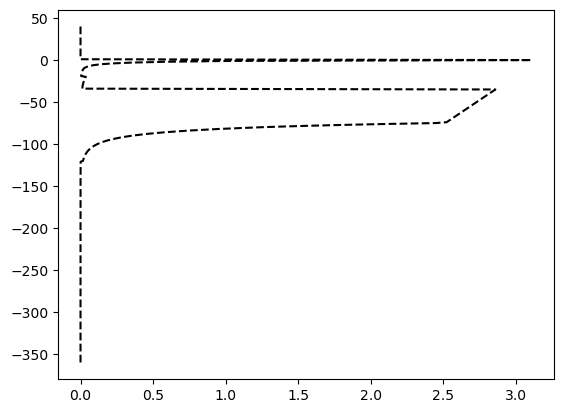

In [33]:
#Viscosity scale factor
C_air = 1.0
C_upper_crust = 1.0
C_lower_crust = 10.0
C_seed = 0.1
C_mlit = 1.0
C_ast = 1.0

#density (kg/m3)
rho_air = 1.0
rho_upper_crust = 2700.0
rho_lower_crust = 2800.0
rho_seed = 2800.0
rho_mlit = 3330.0 #3354.0 #phanerozoic
rho_ast = 3378.0

#radiogenic heat production (W/kg)
H_air = 0.0
# H_upper_crust = 1.25e-6 / 2700.0 #9.259E-10 #old
# H_lower_crust = 0.2e-6 / 2800.0 #2.85E-10 #old
H_upper_crust = 1.67e-6 / 2700.0 #
H_lower_crust = 0.19e-6 / 2800.0 #
H_seed = 0.2e-6 / 2800.0

radiogenic_heat_mlit = True
# radiogenic_heat_mlit = False
if(radiogenic_heat_mlit):
    H_mlit = 9.0e-12
else:
    H_mlit = 0.0 #9.0e-12

H_ast = 0.0 #Turccote book: 7.38e-12 #Default is 0.0

#Pre exponential constant (Pa**-n s**-1)
A_air = 1.0E-18
A_upper_crust = 8.574e-28
A_lower_crust = 8.574e-28
A_seed = 8.574e-28
A_mlit = 2.4168e-15
A_ast = 1.393e-14

#Power law exponent
n_air = 1.0
n_upper_crust = 4.0
n_lower_crust = 4.0
n_seed = 4.0
n_mlit = 3.5
n_ast = 3.0

#Activation energy (J/mol)
Q_air = 0.0
Q_upper_crust = 222.0e3
Q_lower_crust = 222.0e3
Q_seed = 222.0e3
Q_mlit = 540.0e3
Q_ast = 429.0e3

#Activation volume (m3/mol)
V_air = 0.0
V_upper_crust = 0.0
V_lower_crust = 0.0
V_seed = 0.0
V_mlit = 25.0e-6
V_ast = 15.0e-6

sigma_test = calc_YSE(temper_0, z, 
        C_air, C_upper_crust, C_lower_crust, C_mlit, C_ast,
        rho_air, rho_upper_crust, rho_lower_crust, rho_mlit, rho_ast,
        H_air, H_upper_crust, H_lower_crust, H_mlit, H_ast,
        A_air, A_upper_crust, A_lower_crust, A_mlit, A_ast,
        n_air, n_upper_crust, n_lower_crust, n_mlit, n_ast,
        Q_air, Q_upper_crust, Q_lower_crust, Q_mlit, Q_ast,
        V_air, V_upper_crust, V_lower_crust, V_mlit, V_ast,
        thickness_sa = thickness_sa,
        thickness_upper_crust = thickness_upper_crust,
        thickness_lower_crust = thickness_lower_crust,
        thickness_mlit = thickness_mlit,
        thickness_litho = thickness_litho)

plt.plot(sigma_test/1e9, -(z-thickness_sa)/1e3,'--k', label=r'$C_{lc}$=10')

np.float64(1518.4442236024845)